In [51]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay


titanic = pd.read_csv(r"C:\Users\talon\Downloads\train.csv")
mpl.rcParams['font.size'] = 5
#import necessary libraries, read file, and set font size

In [52]:
print(titanic.Survived.describe(),
titanic.Pclass.describe(),
titanic.Sex.describe(),
titanic.Age.describe(),
titanic.SibSp.describe(),
titanic.Parch.describe(),
titanic.Fare.describe(),
sep = '\n\n')
#describe titanic attributes

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

count    891.000000
mean       2.308642
std        0.836071
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: Pclass, dtype: float64

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000

In [53]:
rng = np.random.default_rng()
random_ages = pd.Series(rng.integers(titanic.Age.min(), titanic.Age.max(), size=len(titanic.Age.isna())))
titanic.Age.fillna(random_ages)
# fill na ages with random ages

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    48.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

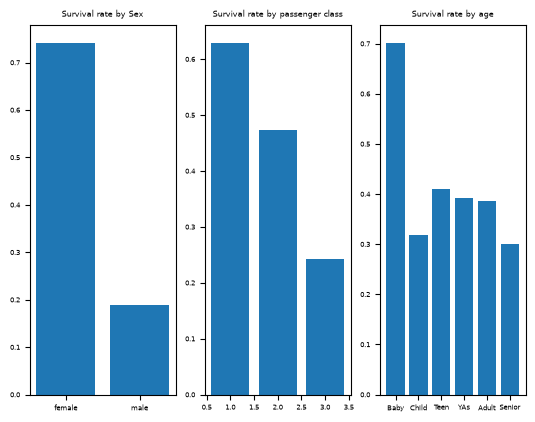

In [54]:
plt.figure()
plt.subplot(131)
sex_data = titanic.groupby('Sex').Survived.sum()/titanic.groupby('Sex').Survived.count()
plt.bar(sex_data.index,sex_data.values)
plt.title('Survival rate by Sex')
# survival rate by sex
plt.subplot(132)
Pclass_data = titanic.groupby('Pclass').Survived.sum()/titanic.groupby('Pclass').Survived.count()
plt.bar(Pclass_data.index, Pclass_data.values)
plt.title('Survival rate by passenger class')
# survival rate by Pclass
plt.subplot(133)
bins = [0, 6, 12, 19, 36, 55, 100]
labels = ['Baby','Child', 'Teen', 'YAs','Adult', 'Senior']
titanic['Age_Group'] = pd.cut(titanic['Age'], bins=bins, labels=labels)
Age_Group_data = titanic.groupby('Age_Group').Survived.sum()/titanic.groupby('Age_Group').Survived.count()
plt.bar(Age_Group_data.index, Age_Group_data.values)
plt.title('Survival rate by age')
plt.show()
# survival rate by age group

In [55]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
def alone(row):
    return row.FamilySize == 1
titanic['IsAlone'] = titanic.apply(alone, axis = 'columns')
def title(row):
    return row.Name[row.Name.index(',')+2:row.Name.index('.')]
titanic['Title'] = titanic.apply(title, axis = 'columns')

#Create attributes FamilySize, IsAlone, and Title using mapping

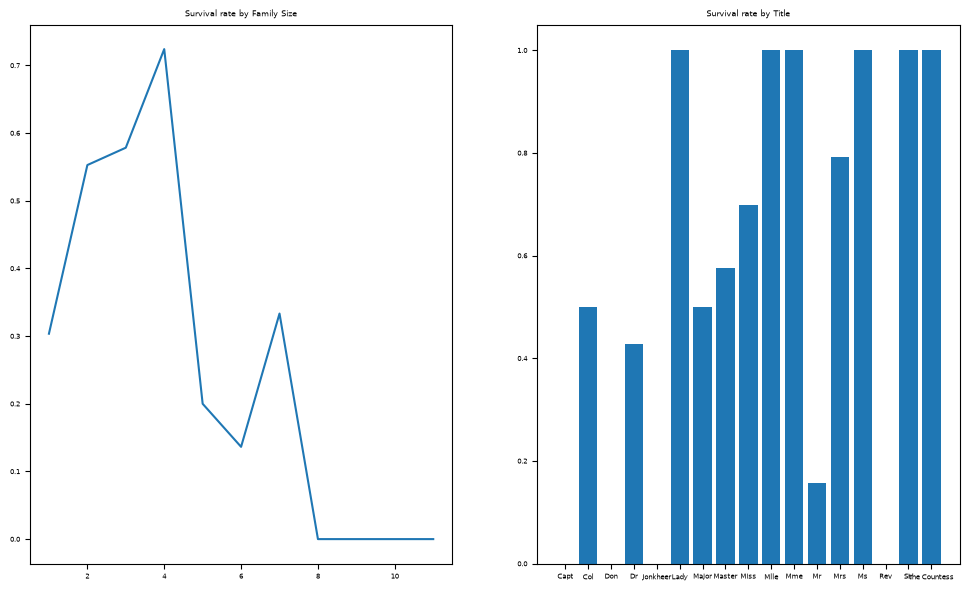

In [56]:
plt.figure(figsize=(12, 7))
plt.subplot(121)
FamilySize_data = titanic.groupby('FamilySize').Survived.sum()/titanic.groupby('FamilySize').Survived.count()
plt.plot(FamilySize_data.index, FamilySize_data.values, markevery =1)
plt.title('Survival rate by Family Size')
# survival rate by family size
plt.subplot(122)
Title_data = titanic.groupby('Title').Survived.sum()/titanic.groupby('Title').Survived.count()
plt.bar(Title_data.index, Title_data.values)
plt.title('Survival rate by Title')
# plot survival rate by title
plt.show()

Who Survived the Titanic and Why:

There were many factors that affected ones odds of surviving the titanic, but by far the most important was gender. Females had almost a 75% chance of survival while males had less than 20%. This is illustrated in the title graph and the sex graph. The next biggest factor was passenger class, with 1st class passengers having about a 60% chance of survival while 3rd class passengers barely having a 20% chance of survival; this is also noticable in the title bar graph. The next largest factor was family size: those with 4 damily members had a 70% chance of survival, while those with 6 had less than a 15% chance of survival. The smallest notable factor was the age group, with babies having an approxamitely 35% higher chance of survival than everyone else.

In [57]:
encode_Sex = {'male': 0, 'female': 1}
titanic['Sex'] = titanic['Sex'].map(encode_Sex)
titanic['Sex'].astype('Int64')
titanic['IsAlone'].astype('Int64')
#encode Sex
features = titanic.drop(columns=['Survived'])
target = titanic['Survived']
#seperate target and features
titanic.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex               int64
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin               str
Embarked            str
Age_Group      category
FamilySize        int64
IsAlone            bool
Title               str
dtype: object

In [58]:
num_pipe = Pipeline(steps = [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
obj_pipe = Pipeline(steps = [('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
num_cols = ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Name', 'Ticket', 'Cabin', 'Embarked']
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', obj_pipe, cat_cols)],
    remainder='drop')
# final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=500))])
# final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=500, solver = 'liblinear', penalty = 'l1'))])
# final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=500, solver = 'liblinear', penalty = 'l2'))])
# final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=500, C = .001))])
# final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=500, C = 1))])
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=500, C = 10))])
#create pipeline
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
final_pipeline.fit(X_train, y_train)
# fit pipeline to data
cross_score = cross_val_score(final_pipeline, X_train, y_train, cv=5, scoring='accuracy')
prepro = final_pipeline.named_steps['preprocessor']
num_tran = prepro.named_transformers_['num']
scaler = num_tran.named_steps['scaler']
coef = final_pipeline.named_steps['classifier'].coef_[0]
summary = pd.DataFrame({'Feature': num_cols, 'Mean': scaler.mean_, 'Std': scaler.scale_, 'Weight': coef[:len(num_cols)]})
print(summary)
print('Cross score:', cross_score.mean())

       Feature        Mean         Std    Weight
0  PassengerId  448.234551  256.551071  0.101155
1       Pclass    2.330056    0.824005 -0.885369
2          Sex    0.344101    0.475074  2.008245
3          Age   29.204129   12.998833 -0.628777
4        SibSp    0.553371    1.175578 -0.416709
5        Parch    0.379213    0.791113 -0.134185
6         Fare   32.586276   51.933021  0.183434
Cross score: 0.8075642667191965


Original cross score: 0.8075347188023244
With solver = 'liblinear', penalty = 'l1': 0.7948882103811681
With solver = 'liblinear', penalty = 'l2': 0.8075347188023244
With C = .001: 0.6348468432975476
With C = 1: 0.8075347188023244
With C = 10: 0.8075642667191965
Best pipeline: C = 10

In [59]:
num_cols_2 = ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare','FamilySize', 'IsAlone']
cat_cols_2 = ['Name', 'Ticket', 'Cabin', 'Embarked', 'Age_Group', 'Title']
preprocessor_2 = ColumnTransformer(transformers=[('num', num_pipe, num_cols_2), ('cat', obj_pipe, cat_cols_2)])
final_pipeline_2 = Pipeline(steps=[('preprocessor', preprocessor_2),('classifier', LogisticRegression(max_iter=500, C = 10))])
final_pipeline_2.fit(X_train, y_train)
cross_score_2 = cross_val_score(final_pipeline_2, X_train, y_train, cv=5, scoring='accuracy')
print(cross_score_2.mean())
#train 2nd model with engineered features

0.8455136412882892


Original Cross score: 0.8075642667191965

Cross score with Family Size and IsAlone: 0.8159952723333005

Cross score with Age Group and Title: 0.8328572835615089

Cross score with all engineered features: 0.8455136412882892

The best score was using all engineered features

In [60]:
probabilities = final_pipeline_2.predict_proba(X_test)
predictions  = []
threshold_table = {'Threshold': [], 'Precision': [], 'Recall': [], 'F1': []}
for i in range(5):
    predictions.append((probabilities >= (i+3)/10).astype(int))
    predictions[i] = np.argmax(predictions[i], axis=1)
    report = classification_report(predictions[i], y_test.to_numpy(), output_dict=True)
    precision = report['0']['precision']
    recall = report['0']['recall']
    f1 = report['0']['f1-score']
    threshold_table['Threshold'].append((i+3)/10)
    threshold_table['Precision'].append(precision)
    threshold_table['Recall'].append(recall)
    threshold_table['F1'].append(f1)
print(pd.DataFrame(threshold_table))



   Threshold  Precision    Recall        F1
0        0.3   0.914286  0.800000  0.853333
1        0.4   0.876190  0.807018  0.840183
2        0.5   0.876190  0.867925  0.872038
3        0.6   0.876190  0.807018  0.840183
4        0.7   0.914286  0.800000  0.853333


.3 and .7 seem to be the best threshold for precision, while .5 is the best for recall, and F1 score.

0.794980694980695


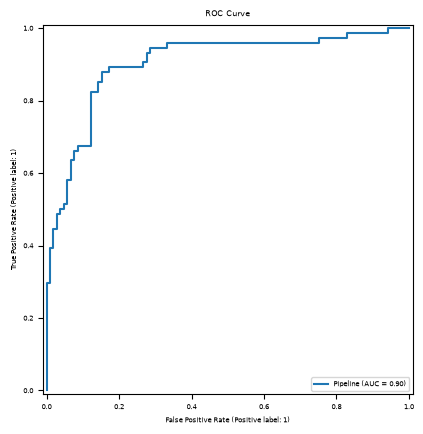

In [61]:
auc_score = roc_auc_score(y_test, predictions[0])
print(auc_score)
RocCurveDisplay.from_estimator(final_pipeline_2, X_test, y_test)
plt.title('ROC Curve')
plt.show()

The auc (area under curve score) can be misleading when there is a severe imbalance (in this case if 95% of people survived and only 5% died), or when the costs are asymetric. In the case of a severe imbalance the auc will reward the models that overly skew to detecting the minority class (in the example those who died). Asymetric costs can also make the auc score less accurate as it will use all thresholds equally when in many scenarios this is not the focus. In the scenario of the titanic, there is not a severe imbalance. Asymetric cost could be an issue if this data was being used to find survivors from a different boat crash, but this model will not be used for that.

In [62]:
test = pd.read_csv(r"C:\Users\talon\Downloads\test.csv")

rng = np.random.default_rng()
random = pd.Series(rng.integers(test.Age.min(), test.Age.max(), size=len(test.Age.isna())))
test.Age.fillna(random)

test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
test['IsAlone'] = test.apply(alone, axis = 'columns')
test['Title'] = test.apply(title, axis = 'columns')
test['Age_Group'] = pd.cut(test['Age'], bins=bins, labels=labels)

test['Sex'] = test['Sex'].map(encode_Sex)
test['Sex'].astype('Int64')
test['IsAlone'].astype('Int64')

submission_predictions = final_pipeline_2.predict_proba(test)
submission_predictions = np.argmax(submission_predictions, axis=1)
submission_pd = pd.DataFrame(test['PassengerId'])
submission_pd['Survived'] = submission_predictions
submission_pd.to_csv("submission.csv", index=False)
# prepare submission for kaggle competition


In the kaggle submission, this model recieved a score of 0.77751, meaning it corectly predicted the survival of 77.751% pf those on the titanic. I would consider this a pretty good score given a real data set that likely had many unpredictable factors that were not visible in the dataset.